✓ Đọc file và chuyển đổi màu thành công!


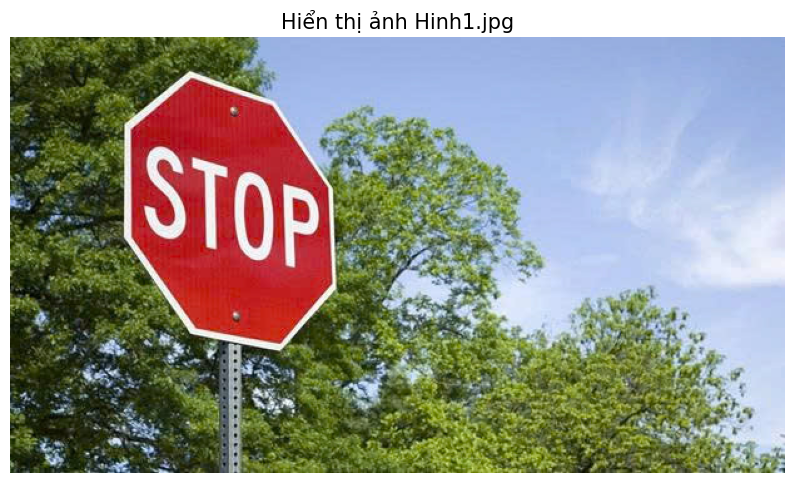

In [8]:
import cv2
import matplotlib.pyplot as plt

# 1. Đọc ảnh từ thư mục hiện tại trên máy Windows của bạn (đã bỏ /content/ của Colab)
img = cv2.imread("hinh1.jpg")

# 2. Kiểm tra xem ảnh có tồn tại hay không để tránh lỗi
if img is None:
    print("LỖI: Không tìm thấy ảnh 'hinh1.jpg'. Vui lòng kiểm tra xem file đã nằm đúng trong thư mục Week7 chưa.")
else:
    # 3. Chuyển đổi hệ màu
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    print("✓ Đọc file và chuyển đổi màu thành công!")
    
    # ----------------------------------------------------
    # (Tùy chọn) Chèn các đoạn code xử lý của bạn ở đây
    # Ví dụ: nhận diện biển báo STOP (stop_data = cv2.CascadeClassifier...)
    # ----------------------------------------------------
    
    # 4. Hiển thị ảnh ra màn hình bằng Matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title('Hiển thị ảnh Hinh1.jpg', fontsize=15)
    plt.axis('off') # Tắt vạch tọa độ
    plt.show()


Tuyệt vời! Hệ thống phát hiện thấy 4 khuôn mặt.


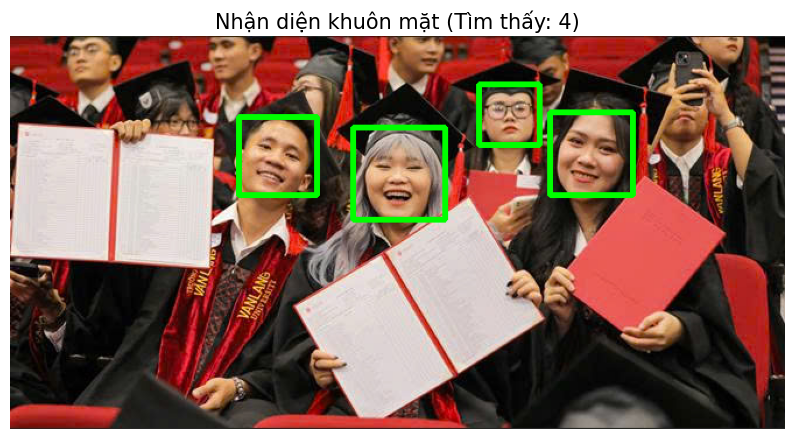

In [1]:
import cv2
import matplotlib.pyplot as plt

# 1. Đọc ảnh và chuyển đổi các hệ màu
img = cv2.imread("hinh2.jpg")

if img is None:
    print("Lỗi: Không tìm thấy file 'hinh2.jpg'. Vui lòng kiểm tra lại đường dẫn!")
else:
    # Ảnh xám img_gray dùng để tính toán nhận diện nhanh hơn
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Ảnh màu img_rgb dùng để vẽ khung xanh và hiển thị trên màn hình
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Khởi tạo tệp dữ liệu nhận diện khuôn mặt (Cascade Classifier)
    face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
    
    # BƯỚC DỰ PHÒNG: Nếu file xml không nằm sát bên file Code, tự động lấy file gốc của OpenCV
    if face_cascade.empty():
        print("Không tìm thấy file xml cục bộ, đang tự động dùng file mặc định của OpenCV...")
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    # 3. Tiến hành quét và dò tìm khuôn mặt trên ảnh xám
    # Tham số chuẩn thường dùng:
    # scaleFactor=1.1 (độ thu phóng ảnh mỗi lần quét)
    # minNeighbors=4  (Số lượng khung chữ nhật lân cận tối thiểu để xác nhận là 1 khuôn mặt, giảm nhiễu)
    found_faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))
    
    amount_found = len(found_faces)

    # 4. Vẽ khung vuông xanh lá (0, 255, 0) quanh các khuôn mặt tìm thấy
    if amount_found != 0:
        print(f"Tuyệt vời! Hệ thống phát hiện thấy {amount_found} khuôn mặt.")
        for (x, y, width, height) in found_faces:
            # GHI CHÚ: Đã sửa lại lỗi ngược tọa độ width/height từ đoạn code tham khảo cũ
            cv2.rectangle(img_rgb, (x, y), (x + width, y + height), (0, 255, 0), 4)
    else:
        print("Không phát hiện ra khuôn mặt nào trong tấm ảnh này.")

    # 5. Hiển thị ảnh kết quả bằng Matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(f'Nhận diện khuôn mặt (Tìm thấy: {amount_found})', fontsize=15)
    plt.axis('off') # Ẩn các vạch tọa độ cho đẹp
    plt.show()


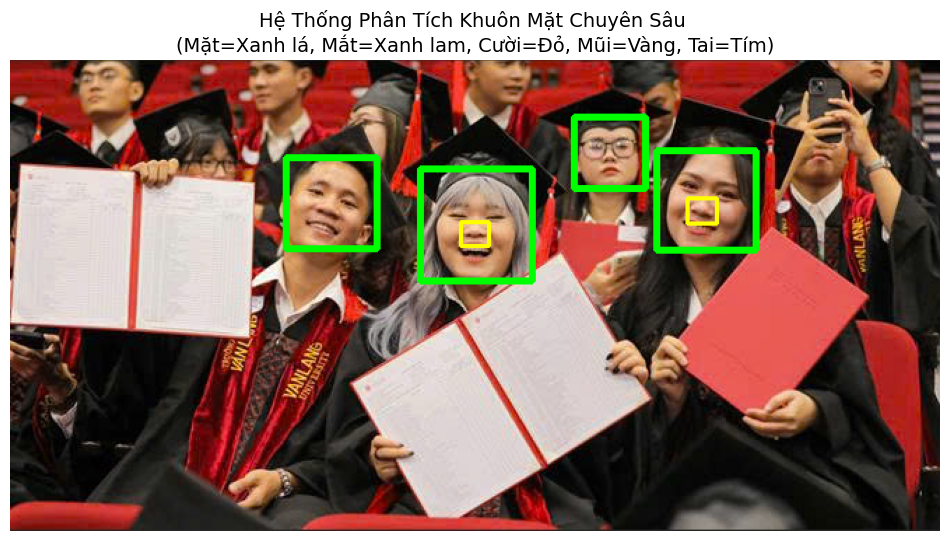

In [10]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("hinh2.jpg")

if img is None:
    print("Lỗi: Không tìm thấy 'hinh2.jpg'.")
else:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Thư mục chứa dữ liệu có sẵn cốt lõi của OpenCV
    cv2_base = cv2.data.haarcascades
    
    # 1. Nạp các Cỗ máy phân loại (Cascade Classifiers)
    face_cascade  = cv2.CascadeClassifier(cv2_base + 'haarcascade_frontalface_default.xml')
    eye_cascade   = cv2.CascadeClassifier(cv2_base + 'haarcascade_eye.xml')
    smile_cascade = cv2.CascadeClassifier(cv2_base + 'haarcascade_smile.xml')
    
    # [DỮ LIỆU TẢI NGOÀI]: Mũi, Miệng, Tai bắt buộc phải nạp từ file thầy cô cung cấp cục bộ
    nose_cascade  = cv2.CascadeClassifier('haarcascade_mcs_nose.xml')
    mouth_cascade = cv2.CascadeClassifier('haarcascade_mcs_mouth.xml')
    lear_cascade  = cv2.CascadeClassifier('haarcascade_mcs_leftear.xml')
    rear_cascade  = cv2.CascadeClassifier('haarcascade_mcs_rightear.xml')
    
    # 2. Xử lý quét: Quét toàn Cục tìm MẶT trước
    faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.15, minNeighbors=5)
    
    for (x, y, w, h) in faces:
        # Nhấn viền xanh lá (Thân) dày cho khuôn mặt tổng thể
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 4)
        
        # CẮT VÙNG ROI (Chỉ lấy mảng lưới Pixel dính vào hình vuông trên Face) để quét các bộ phận nhỏ
        roi_gray = img_gray[y:y+h, x:x+w]
        roi_color = img_rgb[y:y+h, x:x+w]
        
        # --- A. QUÉT MẮT (Viền Xanh Lam) ---
        # Tham số lớn (minNeighbors=10) để tránh tìm ra dải tàn nhang nhầm thành mắt
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10, minSize=(15, 15))
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 0, 255), 2)
            
        # --- B. QUÉT NỤ CƯỜI / MIỆNG DƯỚI (Viền Đỏ) ---
        smiles = smile_cascade.detectMultiScale(roi_gray, scaleFactor=1.7, minNeighbors=20, minSize=(25, 25))
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (255, 0, 0), 2)
            
        # --- C. QUÉT MŨI (Viền Vàng - Nếu bạn có file haarcascade_mcs_nose) ---
        if not nose_cascade.empty():
            noses = nose_cascade.detectMultiScale(roi_gray, scaleFactor=1.3, minNeighbors=5)
            for (nx, ny, nw, nh) in noses:
                cv2.rectangle(roi_color, (nx, ny), (nx+nw, ny+nh), (255, 255, 0), 2)
                
        # --- D. QUÉT TAI (Viền Tím) ---
        if not lear_cascade.empty():
            left_ears = lear_cascade.detectMultiScale(roi_gray, 1.1, 3)
            for (lx, ly, lw, lh) in left_ears:
                cv2.rectangle(roi_color, (lx, ly), (lx+lw, ly+lh), (255, 0, 255), 2)

    # 3. Hiển thị Output
    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.title('Hệ Thống Phân Tích Khuôn Mặt Chuyên Sâu \n(Mặt=Xanh lá, Mắt=Xanh lam, Cười=Đỏ, Mũi=Vàng, Tai=Tím)', fontsize=14)
    plt.axis('off')
    plt.show()
